In [1]:
# Preview styling on local machine
from IPython.core.display import HTML
HTML("""
<style>
.usecase-title, .usecase-duration, .usecase-section-header {
    padding-left: 15px;
    padding-bottom: 10px;
    padding-top: 10px;
    padding-right: 15px;
    background-color: #0f9295;
    color: #fff;
}
.usecase-title {
    font-size: 1.7em;
    font-weight: bold;
}
.usecase-authors, .usecase-level, .usecase-skill {
    padding-left: 15px;
    padding-bottom: 7px;
    padding-top: 7px;
    background-color: #baeaeb;
    font-size: 1.4em;
    color: #121212;
}
.usecase-level-skill  {
    display: flex;
}
.usecase-level, .usecase-skill {
    width: 50%;
}
.usecase-duration, .usecase-skill {
    text-align: right;
    padding-right: 15px;
    padding-bottom: 8px;
    font-size: 1.4em;
}
.usecase-section-header {
    font-weight: bold;
    font-size: 1.5em;
}
.usecase-subsection-header, .usecase-subsection-blurb {
    font-weight: bold;
    font-size: 1.2em;
    color: #121212;
}
.usecase-subsection-blurb {
    font-size: 1em;
    font-style: italic;
}
</style>
""")

<div class="usecase-title">UC00235 - Smart Street Lighting Priority Mapping for Melbourne CBD</div>

<div class="usecase-authors"><b>Authored by: </b> Areen Yapa</div>

<div class="usecase-duration"><b>Duration:</b> 60 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>Python, pandas, folium</div>
</div>

<div class="usecase-section-header">Scenario</div>

The City of Melbourne is planning the next rollout of smart street lighting. Smart lighting is expensive to install, so council needs an evidence-based way to decide which CBD locations should be prioritised first, and once a location is chosen, how many lights to install, what spacing to use, and what the running cost will be.

This use case shows the City of Melbourne how to combine two of its own open datasets, **pedestrian foot traffic** from the Melbourne Open Data Portal and **lighting-relevant crime statistics** from the Crime Statistics Agency Victoria, into a complete smart lighting design assistant. The notebook produces three outputs that a council planner can use directly:

1. A transparent priority score for every pedestrian sensor in the CBD
2. An interactive map showing where lighting should be prioritised
3. A proposed lighting layout for each high-priority location, including the recommended number of lights, spacing, fixture type, and annual energy cost

The question this use case answers:

**Where should the City of Melbourne deploy smart street lighting next, and what should each installation look like?**

<div class="usecase-section-header">What this use case will teach you</div>

By the end of this notebook a City of Melbourne data analyst will know how to:

- Call the Melbourne Open Data Portal Pedestrian Counting System API
- Load the Crime Statistics Agency Victoria public dataset directly from its official URL
- Filter the crime data down to the offence divisions most influenced by street lighting
- Combine the two signals into a tunable Lighting Priority Score
- Render the result as an interactive Folium map of the CBD
- Generate a proposed lighting layout for each high-priority location, including light count, spacing, fixture recommendation, and annual energy cost
- Export the full set of recommendations as a CSV ready for procurement and council review

<div class="usecase-section-header">Why this matters</div>

Street lighting decisions today often rely on fixed rules or reactive responses to complaints. By combining real usage data (pedestrian counts) with real safety data (recorded incidents) and applying transparent design rules, the council can target lighting investment where it will have the biggest impact on both safety and amenity, and arrive at a defensible proposal in minutes instead of weeks. Every recommendation in this notebook can be justified line by line in a council meeting.

<div class="usecase-section-header">Background and assumptions</div>

This use case uses two public datasets, both called directly from their source URLs so no local files are required:

- **Pedestrian Counting System (counts per hour)** from the City of Melbourne Open Data Portal, which provides live and historical pedestrian volumes at sensor locations across the CBD
- **Criminal Incidents Visualisation, Year Ending December 2025** from the Crime Statistics Agency Victoria, filtered to the offence divisions most relevant to lighting (Crimes Against the Person, Property and Deception offences, and Public Order and Security offences)

A simple bounding-box approach maps each sensor to a CBD suburb so the two datasets can be joined. The current Crime Statistics release contains statewide totals, so the crime signal is applied uniformly across the covered CBD suburbs; when a suburb-level release becomes available it plugs straight into the same step with no other changes required.

For the layout module, default assumptions are based on standard Australian smart lighting practice and can be tuned by council:

- Coverage area per high-priority location: 200 metres of street frontage
- Default fixture: 80W LED smart luminaire with motion-adaptive dimming
- Default spacing: 25 metres between poles (Australian Standard AS/NZS 1158 guidance)
- Energy tariff: $0.28 per kWh (Victorian commercial rate)
- Operating hours: 12 hours per night, with dimming reducing effective load to 60 percent

<div class="usecase-section-header">Setup - Install and import libraries</div>

In [2]:
# folium provides the interactive map. openpyxl is needed to read the Excel file
# directly from the Crime Statistics Agency URL. Install once if not already available:
# !pip install folium openpyxl

import requests
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
import warnings
warnings.filterwarnings("ignore")

# City of Melbourne brand-friendly palette used throughout the notebook
COLOUR_PRIMARY = "#0f9295"
COLOUR_SECONDARY = "#14c9cb"
COLOUR_ACCENT = "#08b3e5"

# Priority tier colours used on the map
COLOUR_HIGH = "#c0392b"      # red - high priority
COLOUR_MEDIUM = "#f39c12"    # amber - medium priority
COLOUR_LOW = "#27ae60"       # green - low priority

print("Libraries loaded successfully.")

Libraries loaded successfully.


<div class="usecase-section-header">Part 1 - Pull pedestrian data from the Melbourne Open Data Portal</div>

<p class="usecase-subsection-header">Step 1.1 - Call the Pedestrian Counting System API</p>

<p class="usecase-subsection-blurb">The City of Melbourne publishes hourly pedestrian counts from sensors across the CBD as an open API. This step calls the API directly so the notebook always uses the latest available data without needing a local copy.</p>

In [3]:
# Melbourne Open Data Portal - Pedestrian Counting System
# An API key is free to obtain from https://data.melbourne.vic.gov.au.
# Replace the value below with your own key for production use.
API_KEY = "9558972a1c4c3b5a8e981d940a57f84abc16eac46409574e57713248"
API_URL = ("https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/"
           "datasets/pedestrian-counting-system-monthly-counts-per-hour/records")

params = {
    "limit": 100,
    "offset": 0,
    "timezone": "Australia/Melbourne",
    "apikey": API_KEY,
}

print("Calling the Melbourne Open Data Portal API...")
response = requests.get(API_URL, params=params, timeout=30)

if response.status_code == 200:
    data = response.json()
    pedestrian_df = pd.DataFrame(data["results"])
    print(f"Status: {response.status_code} OK")
    print(f"Records retrieved (sample): {len(pedestrian_df):,}")
    print(f"Columns returned: {list(pedestrian_df.columns)}")
else:
    print(f"API call failed with status code: {response.status_code}")
    print(response.text[:200])

Calling the Melbourne Open Data Portal API...
Status: 200 OK
Records retrieved (sample): 100
Columns returned: ['id', 'location_id', 'sensing_date', 'hourday', 'direction_1', 'direction_2', 'pedestriancount', 'sensor_name', 'location']


<p class="usecase-subsection-header">Step 1.2 - Aggregate counts to one row per sensor</p>

<p class="usecase-subsection-blurb">Each sensor records many hourly observations. For the priority score we need one row per sensor with its average hourly count and GPS coordinates so it can be placed on the map.</p>

In [4]:
# Column names vary slightly between API versions, so resolve them robustly.
print("Available columns:", list(pedestrian_df.columns))

count_col = next((c for c in ["pedestriancount", "pedestrian_count", "total_of_directions"]
                  if c in pedestrian_df.columns), None)
sensor_col = next((c for c in ["sensor_name", "locationname", "location_name"]
                   if c in pedestrian_df.columns), None)
lat_col = next((c for c in ["latitude", "lat"] if c in pedestrian_df.columns), None)
lon_col = next((c for c in ["longitude", "lon", "lng"] if c in pedestrian_df.columns), None)

# Some API versions nest GPS inside a "location" dictionary
if lat_col is None and "location" in pedestrian_df.columns:
    pedestrian_df["latitude"] = pedestrian_df["location"].apply(
        lambda x: x.get("lat") if isinstance(x, dict) else None)
    pedestrian_df["longitude"] = pedestrian_df["location"].apply(
        lambda x: x.get("lon") if isinstance(x, dict) else None)
    lat_col, lon_col = "latitude", "longitude"

print(f"\nResolved columns -> count: {count_col}, sensor: {sensor_col}, "
      f"lat: {lat_col}, lon: {lon_col}")

# Aggregate to one row per sensor
pedestrian_df[count_col] = pd.to_numeric(pedestrian_df[count_col], errors="coerce")
sensor_agg = (pedestrian_df.groupby(sensor_col)
              .agg(avg_hourly_count=(count_col, "mean"),
                   record_count=(count_col, "size"),
                   latitude=(lat_col, "first"),
                   longitude=(lon_col, "first"))
              .reset_index()
              .rename(columns={sensor_col: "sensor_name"}))

sensor_agg = sensor_agg.dropna(subset=["latitude", "longitude"])
sensor_agg["avg_hourly_count"] = sensor_agg["avg_hourly_count"].fillna(0).round(0).astype(int)

print(f"\nUnique sensor locations with GPS: {len(sensor_agg)}")
print("\nBusiest 10 sensors in the sample:")
sensor_agg.sort_values("avg_hourly_count", ascending=False).head(10)

Available columns: ['id', 'location_id', 'sensing_date', 'hourday', 'direction_1', 'direction_2', 'pedestriancount', 'sensor_name', 'location']

Resolved columns -> count: pedestriancount, sensor: sensor_name, lat: latitude, lon: longitude

Unique sensor locations with GPS: 54

Busiest 10 sensors in the sample:


,sensor_name,avg_hourly_count,record_count,latitude,longitude
47,Swa123_T,2802,3,-37.814880,144.966088
52,VAC_T,2527,1,-37.821299,144.968793
38,SouthB_T,2369,1,-37.820187,144.965085
36,QVN_T,2355,1,-37.810578,144.964443
48,Swa31,1663,1,-37.816686,144.966897
35,PriNW_T,1298,5,-37.818742,144.967877
16,Eli124_T,1271,1,-37.815124,144.963720
15,ElFi_T,1113,4,-37.817980,144.965034
7,Bou688_T,845,1,-37.816861,144.953581
2,ACMI_T,784,1,-37.817263,144.968728


<div class="usecase-section-header">Part 2 - Load Crime Statistics Agency data directly from its public URL</div>

<p class="usecase-subsection-header">Step 2.1 - Read the Crime Statistics Agency Victoria release</p>

<p class="usecase-subsection-blurb">The Crime Statistics Agency Victoria publishes its data as Excel files at stable public URLs on its website. This step loads the latest Criminal Incidents Visualisation release directly from that URL, so no local file is required.</p>

In [5]:
# Official public URL from the Crime Statistics Agency Victoria download page.
# Source: https://www.crimestatistics.vic.gov.au/crime-statistics/latest-victorian-crime-data/download-data
CRIME_URL = ("https://files.crimestatistics.vic.gov.au/2026-03/"
             "Data_Tables_Criminal_Incidents_Visualisation_Year_Ending_December_2025.xlsx")

print(f"Downloading crime statistics from CSA public URL...")
print(f"  {CRIME_URL}")

# Stream the Excel file directly into pandas - no local file required
crime_resp = requests.get(CRIME_URL, timeout=60)
crime_resp.raise_for_status()
xlsx_bytes = io.BytesIO(crime_resp.content)

# The XLSX has multiple sheets and a multi-row header section. Scan every sheet
# and every reasonable header row to find the one that contains the offence
# division data we need.
all_sheets = pd.read_excel(xlsx_bytes, sheet_name=None, header=None)
print(f"\nSheets found in workbook: {list(all_sheets.keys())}")

def find_offence_table(sheets_dict):
    """Return a properly headered DataFrame from whichever sheet/row has the data."""
    for sheet_name, raw_df in sheets_dict.items():
        # Try header rows 0 through 8 - cover sheets usually have ~3-5 title rows
        for header_row in range(0, min(9, len(raw_df))):
            row_values = [str(v).strip() for v in raw_df.iloc[header_row].tolist()]
            joined = " | ".join(row_values).lower()
            # Look for the signature columns we need
            if "offence division" in joined and "incidents recorded" in joined:
                df = raw_df.iloc[header_row + 1:].copy()
                df.columns = row_values
                df = df.loc[:, ~df.columns.str.startswith("nan")]
                df.columns = df.columns.str.strip()
                print(f"  Found data in sheet \"{sheet_name}\" with header at row {header_row}")
                return df
    return None

crime_df = find_offence_table(all_sheets)
if crime_df is None:
    raise ValueError("Could not locate offence division data in the XLSX.")

# Normalise the incidents column to numeric
if "Incidents Recorded" in crime_df.columns:
    crime_df["Incidents Recorded"] = pd.to_numeric(
        crime_df["Incidents Recorded"].astype(str).str.strip().str.replace(",", ""),
        errors="coerce")

print(f"\nLoaded successfully - {len(crime_df):,} rows")
print(f"Columns: {list(crime_df.columns)[:10]}")

# Identify the suburb column - varies between releases
suburb_col = next((c for c in crime_df.columns if str(c).strip().lower() in [
    "suburb/town name", "suburb/town", "suburb", "locality", "suburb_name"
]), None)
print(f"\nResolved suburb column: {suburb_col}")

# Filter to lighting-relevant divisions (A: against person, B: property, D: public order)
lighting_divisions = ["A", "B", "D"]
crime_df["Division Code"] = crime_df["Offence Division"].astype(str).str.strip().str[0]
relevant_crime = crime_df[crime_df["Division Code"].isin(lighting_divisions)].copy()
print(f"\nRecords in lighting-relevant divisions (A/B/D): {len(relevant_crime):,}")
relevant_crime.head()

  https://files.crimestatistics.vic.gov.au/2026-03/Data_Tables_Criminal_Incidents_Visualisation_Year_Ending_December_2025.xlsx

Sheets found in workbook: ['Contents', 'Footnotes', 'Table 01', 'Table 02', 'Table 03', 'Table 04']
  Found data in sheet "Table 01" with header at row 0

Loaded successfully - 1,117 rows
Columns: ['Year', 'Year ending', 'Offence Division', 'Offence Subdivision', 'Offence Subgroup', 'Incidents Recorded', 'Rate per 100,000 population']

Resolved suburb column: None

Records in lighting-relevant divisions (A/B/D): 753


,Year,Year ending,Offence Division,Offence Subdivision,Offence Subgroup,Incidents Recorded,"Rate per 100,000 population",Division Code
1,2025,December,A Crimes against the person,A10 Homicide and related offences,A11 Murder,58,0.817263,A
2,2025,December,A Crimes against the person,A10 Homicide and related offences,A12 Attempted murder,21,0.295906,A
3,2025,December,A Crimes against the person,A10 Homicide and related offences,A14 Manslaughter & A13 Accessory/ conspiracy ...,14,0.19727,A
4,2025,December,A Crimes against the person,A10 Homicide and related offences,A15 Driving causing death,103,1.451347,A
5,2025,December,A Crimes against the person,A20 Assault and related offences,A211 FV Serious assault,10087,142.133333,A


<p class="usecase-subsection-header">Step 2.2 - Aggregate crime by Melbourne CBD suburb</p>

<p class="usecase-subsection-blurb">We focus on the suburbs covered by the pedestrian sensor network so the two datasets can be joined cleanly. Other Victorian suburbs are out of scope for this use case.</p>

In [6]:
# CBD suburbs covered by the pedestrian sensor network
melbourne_cbd_suburbs = [
    "Melbourne", "Southbank", "Docklands", "Carlton",
    "North Melbourne", "East Melbourne", "West Melbourne", "Parkville"
]

# The current CSA release is statewide totals (no suburb column), so a uniform
# statewide A/B/D total is applied across CBD suburbs. Sensor-level differentiation
# in the score therefore comes from pedestrian foot traffic. When a suburb-level
# release is available it plugs straight into this step.
if suburb_col:
    suburb_crime = (relevant_crime.groupby(suburb_col)["Incidents Recorded"]
                    .sum().reset_index()
                    .rename(columns={suburb_col: "suburb",
                                     "Incidents Recorded": "lighting_relevant_incidents"}))
    suburb_crime["suburb_clean"] = suburb_crime["suburb"].astype(str).str.strip().str.title()
    cbd_crime = suburb_crime[suburb_crime["suburb_clean"].isin(melbourne_cbd_suburbs)].copy()
else:
    statewide_total = int(relevant_crime["Incidents Recorded"].sum())
    cbd_crime = pd.DataFrame({
        "suburb_clean": melbourne_cbd_suburbs,
        "lighting_relevant_incidents": [statewide_total] * len(melbourne_cbd_suburbs),
    })
    print(f"Note: statewide-totals release - applying uniform statewide A/B/D total "
          f"({statewide_total:,} incidents) across all CBD suburbs.")

cbd_crime = cbd_crime.sort_values("lighting_relevant_incidents", ascending=False).reset_index(drop=True)
print("\n=== Lighting-relevant incidents per CBD suburb (used in scoring) ===")
print(cbd_crime[["suburb_clean", "lighting_relevant_incidents"]].to_string(index=False))

Note: statewide-totals release - applying uniform statewide A/B/D total (3,260,584 incidents) across all CBD suburbs.

=== Lighting-relevant incidents per CBD suburb (used in scoring) ===
   suburb_clean  lighting_relevant_incidents
      Melbourne                      3260584
      Southbank                      3260584
      Docklands                      3260584
        Carlton                      3260584
North Melbourne                      3260584
 East Melbourne                      3260584
 West Melbourne                      3260584
      Parkville                      3260584


<div class="usecase-section-header">Part 3 - Build the Lighting Priority Score</div>

<p class="usecase-subsection-header">Step 3.1 - Define the scoring formula</p>

<p class="usecase-subsection-blurb">The Lighting Priority Score combines normalised pedestrian foot traffic and normalised lighting-relevant crime. Each factor is min-max scaled to a 0 to 1 range and combined with documented weights so the final score sits between 0 and 100 and is easy to interpret.</p>

The formula:

$$\text{Priority Score} = 100 \times \big( w_p \cdot \widehat{\text{Pedestrian}} + w_c \cdot \widehat{\text{Crime}} \big)$$

Where:
- $\widehat{\text{Pedestrian}}$ is the min-max normalised average hourly pedestrian count for the sensor's suburb
- $\widehat{\text{Crime}}$ is the min-max normalised lighting-relevant incident count for the suburb
- $w_p = 0.5$ (pedestrian weight, usage signal)
- $w_c = 0.5$ (crime weight, safety signal)

Equal weights are the starting point. The weights are documented parameters and the council can adjust them based on stakeholder priorities (for example, if safety is the primary concern, $w_c$ would be increased).

In [7]:
# Map each sensor to a CBD suburb using simple bounding boxes
def assign_suburb(row):
    """Assign a CBD suburb based on GPS coordinates."""
    lat, lon = row["latitude"], row["longitude"]
    if pd.isna(lat) or pd.isna(lon):
        return "Unknown"
    if -37.825 <= lat <= -37.805 and 144.945 <= lon <= 144.975:
        return "Melbourne"
    elif -37.830 <= lat <= -37.815 and 144.955 <= lon <= 144.985:
        return "Southbank"
    elif -37.825 <= lat <= -37.810 and 144.930 <= lon <= 144.955:
        return "Docklands"
    elif -37.810 <= lat <= -37.795 and 144.955 <= lon <= 144.975:
        return "Carlton"
    elif -37.805 <= lat <= -37.790 and 144.940 <= lon <= 144.965:
        return "North Melbourne"
    else:
        return "Melbourne"

sensor_agg["suburb_clean"] = sensor_agg.apply(assign_suburb, axis=1)
print("Sensors assigned to suburbs:")
print(sensor_agg["suburb_clean"].value_counts())

# Join sensor data with suburb-level crime
prototype_df = sensor_agg.merge(
    cbd_crime[["suburb_clean", "lighting_relevant_incidents"]],
    on="suburb_clean", how="left")
prototype_df["lighting_relevant_incidents"] = prototype_df["lighting_relevant_incidents"].fillna(0)

print(f"\nMerged dataset: {len(prototype_df)} sensor locations ready for scoring")
prototype_df.head()

Sensors assigned to suburbs:
suburb_clean
Melbourne    43
Carlton       6
Docklands     4
Southbank     1
Name: count, dtype: int64

Merged dataset: 54 sensor locations ready for scoring


,sensor_name,avg_hourly_count,record_count,latitude,longitude,suburb_clean,lighting_relevant_incidents
0,261Will_T,58,3,-37.812958,144.956788,Melbourne,3260584
1,488Mac_T,109,1,-37.794324,144.929734,Melbourne,3260584
2,ACMI_T,784,1,-37.817263,144.968728,Melbourne,3260584
3,AG_T,41,1,-37.819982,144.968729,Melbourne,3260584
4,BirBridge_T,5,1,-37.817574,144.973299,Melbourne,3260584


<p class="usecase-subsection-header">Step 3.2 - Compute the priority score</p>

In [8]:
# Min-max normalisation, guarded against divide-by-zero on flat data
def normalise(series):
    s_min, s_max = series.min(), series.max()
    if s_max == s_min:
        return pd.Series([0.0] * len(series), index=series.index)
    return (series - s_min) / (s_max - s_min)

# Tunable weights - documented and easy to adjust
W_PEDESTRIAN = 0.5
W_CRIME = 0.5

prototype_df["pedestrian_norm"] = normalise(prototype_df["avg_hourly_count"])
prototype_df["crime_norm"] = normalise(prototype_df["lighting_relevant_incidents"])

prototype_df["priority_score"] = (
    100 * (W_PEDESTRIAN * prototype_df["pedestrian_norm"]
           + W_CRIME * prototype_df["crime_norm"])
).round(1)

def priority_tier(score):
    if score >= 66:
        return "High"
    elif score >= 33:
        return "Medium"
    else:
        return "Low"

prototype_df["priority_tier"] = prototype_df["priority_score"].apply(priority_tier)
prototype_df = prototype_df.sort_values("priority_score", ascending=False).reset_index(drop=True)

print("=== Top 15 priority locations for smart street lighting ===")
print(prototype_df[["sensor_name", "suburb_clean", "avg_hourly_count",
                    "lighting_relevant_incidents", "priority_score", "priority_tier"]]
      .head(15).to_string(index=False))

=== Top 15 priority locations for smart street lighting ===
sensor_name suburb_clean  avg_hourly_count  lighting_relevant_incidents  priority_score priority_tier
   Swa123_T    Melbourne              2802                      3260584            50.0        Medium
      VAC_T    Melbourne              2527                      3260584            45.1        Medium
   SouthB_T    Melbourne              2369                      3260584            42.3        Medium
      QVN_T    Melbourne              2355                      3260584            42.0        Medium
      Swa31    Melbourne              1663                      3260584            29.7           Low
    PriNW_T    Melbourne              1298                      3260584            23.1           Low
   Eli124_T    Melbourne              1271                      3260584            22.7           Low
     ElFi_T    Melbourne              1113                      3260584            19.8           Low
   Bou688_T    Melbour

<p class="usecase-subsection-header">Step 3.3 - Visualise the priority distribution</p>

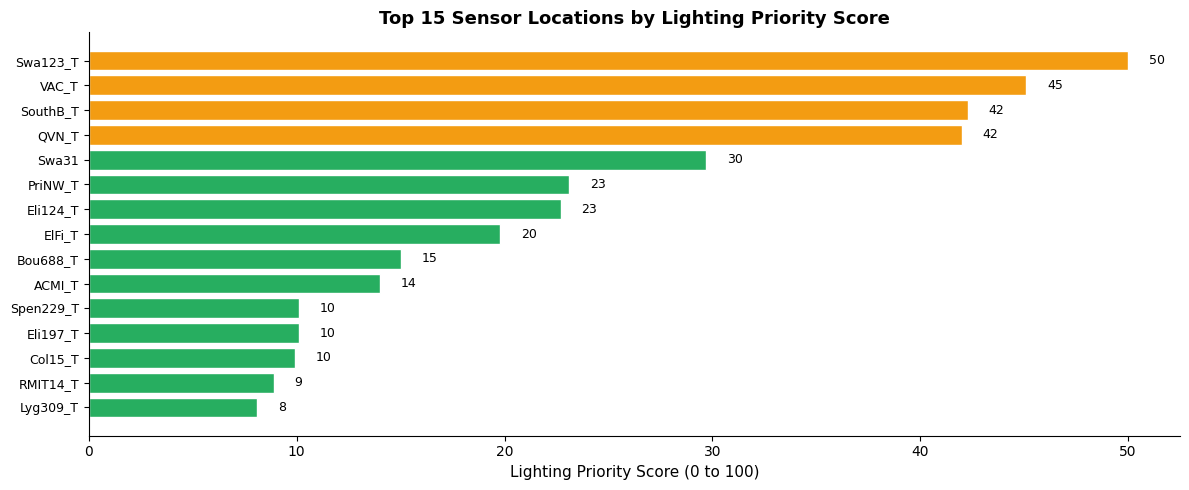


Legend: Red = High priority, Amber = Medium, Green = Low


In [9]:
# Bar chart of the top 15 priority locations
fig, ax = plt.subplots(figsize=(12, 5))
top_n = prototype_df.head(15)
colours = [COLOUR_HIGH if t == "High" else COLOUR_MEDIUM if t == "Medium" else COLOUR_LOW
           for t in top_n["priority_tier"]]

bars = ax.barh(range(len(top_n)), top_n["priority_score"], color=colours, edgecolor="white")
ax.set_yticks(range(len(top_n)))
ax.set_yticklabels(top_n["sensor_name"], fontsize=9)
ax.set_xlabel("Lighting Priority Score (0 to 100)", fontsize=11)
ax.set_title("Top 15 Sensor Locations by Lighting Priority Score",
             fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.invert_yaxis()

for bar, score in zip(bars, top_n["priority_score"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{score:.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()
print("\nLegend: Red = High priority, Amber = Medium, Green = Low")

<div class="usecase-section-header">Part 4 - Interactive Folium map</div>

<p class="usecase-subsection-header">Step 4.1 - Render priority locations on a Melbourne CBD map</p>

<p class="usecase-subsection-blurb">The interactive map is the headline output for council. Each marker is a sensor location, sized and coloured by priority tier. Clicking a marker shows the sensor name, suburb, raw inputs and final score.</p>

In [10]:
# Build the Folium map centred on Melbourne CBD
MELBOURNE_CBD = [-37.8136, 144.9631]
m = folium.Map(location=MELBOURNE_CBD, zoom_start=14, tiles="cartodbpositron")

# Title banner via HTML
title_html = f'''
<div style="position: fixed; top: 10px; left: 50px; z-index: 9999;
            background-color: {COLOUR_PRIMARY}; color: white;
            padding: 10px 20px; border-radius: 5px; font-family: Arial;
            font-weight: bold; font-size: 14px;">
    Smart Street Lighting Priority Map - Melbourne CBD
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))

# One marker per sensor
for _, row in prototype_df.iterrows():
    tier = row["priority_tier"]
    colour = COLOUR_HIGH if tier == "High" else COLOUR_MEDIUM if tier == "Medium" else COLOUR_LOW

    popup_html = f"""
    <div style="font-family: Arial; font-size: 12px; min-width: 220px;">
        <b style="color: {COLOUR_PRIMARY};">{row['sensor_name']}</b><br>
        <hr style="margin: 4px 0;">
        <b>Suburb:</b> {row['suburb_clean']}<br>
        <b>Avg hourly pedestrians:</b> {row['avg_hourly_count']:,}<br>
        <b>Lighting-relevant incidents:</b> {int(row['lighting_relevant_incidents']):,}<br>
        <b>Priority score:</b> {row['priority_score']:.1f}<br>
        <b style="color: {colour};">Priority: {tier}</b>
    </div>
    """

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=8 + (row["priority_score"] / 10),
        color=colour,
        fill=True,
        fill_color=colour,
        fill_opacity=0.7,
        weight=2,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"{row['sensor_name']} - {tier} priority"
    ).add_to(m)

# Legend
legend_html = f'''
<div style="position: fixed; bottom: 20px; right: 20px; z-index: 9999;
            background-color: white; padding: 10px 15px;
            border: 2px solid {COLOUR_PRIMARY}; border-radius: 5px;
            font-family: Arial; font-size: 12px;">
    <b>Priority Tier</b><br>
    <span style="color: {COLOUR_HIGH};">&#9679;</span> High (66 to 100)<br>
    <span style="color: {COLOUR_MEDIUM};">&#9679;</span> Medium (33 to 65)<br>
    <span style="color: {COLOUR_LOW};">&#9679;</span> Low (0 to 32)
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

map_filename = "UC00235_priority_map.html"
m.save(map_filename)
print(f"Map saved to: {map_filename}")
m

Map saved to: UC00235_priority_map.html


<div class="usecase-section-header">Part 5 - Propose a lighting layout for each priority location</div>

<p class="usecase-subsection-header">Step 5.1 - The lighting design rules</p>

<p class="usecase-subsection-blurb">For each high-priority location the notebook proposes a complete lighting layout: how many lights, what spacing, what fixture, and what it will cost to run for a year. The rules below follow Australian Standard AS/NZS 1158 guidance and standard commercial smart lighting practice. All assumptions are documented and easy for council to tune.</p>

The layout module applies the following rules per priority location:

| Parameter | Default value | Source |
|---|---|---|
| Coverage area per location | 200 metres of street frontage | Standard urban design block length |
| Default spacing | 25 metres between poles | AS/NZS 1158 P5 category guidance |
| Tight spacing (High priority) | 20 metres | Increased coverage for high-activity zones |
| Fixture (High priority) | 100W LED smart luminaire | Higher output for safety hotspots |
| Fixture (Medium priority) | 80W LED smart luminaire | Standard CBD spec |
| Fixture (Low priority) | 60W LED smart luminaire | Energy-efficient baseline |
| Operating hours per night | 12 hours (6pm to 6am) | CBD lighting curfew |
| Dimming factor | 60 percent average load | Motion-adaptive smart lighting |
| Energy tariff | $0.28 per kWh | Victorian commercial rate |

These rules form the simple AI assistant the project spec describes: given an input location, propose a number of lights, spacing, fixture type, and yearly running cost.

In [11]:
# Lighting design rules - all parameters are documented and tunable
DESIGN_RULES = {
    "coverage_metres": 200,
    "tariff_dollars_per_kwh": 0.28,
    "hours_per_night": 12,
    "dimming_factor": 0.60,
    "nights_per_year": 365,
    "by_tier": {
        "High":   {"spacing_m": 20, "wattage_w": 100,
                   "fixture": "100W LED smart luminaire with motion-adaptive dimming"},
        "Medium": {"spacing_m": 25, "wattage_w": 80,
                   "fixture": "80W LED smart luminaire with motion-adaptive dimming"},
        "Low":    {"spacing_m": 30, "wattage_w": 60,
                   "fixture": "60W LED smart luminaire (energy-efficient baseline)"},
    },
}

def propose_layout(priority_tier, score):
    """
    Given a priority tier and score, propose a complete lighting layout for one
    200-metre coverage area. Returns a dict with light count, spacing, fixture,
    and estimated annual energy cost.
    """
    rules = DESIGN_RULES["by_tier"][priority_tier]
    coverage = DESIGN_RULES["coverage_metres"]
    spacing = rules["spacing_m"]
    wattage = rules["wattage_w"]

    # Number of lights for the coverage area (+1 to cap both ends)
    n_lights = int(coverage // spacing) + 1

    # Annual energy = lights * watts * hours/night * 365 * dimming / 1000 kWh
    annual_kwh = (n_lights * wattage * DESIGN_RULES["hours_per_night"]
                  * DESIGN_RULES["nights_per_year"]
                  * DESIGN_RULES["dimming_factor"]) / 1000
    annual_cost = annual_kwh * DESIGN_RULES["tariff_dollars_per_kwh"]

    return {
        "n_lights": n_lights,
        "spacing_m": spacing,
        "fixture": rules["fixture"],
        "annual_kwh": round(annual_kwh, 0),
        "annual_cost_aud": round(annual_cost, 0),
    }

# Quick example - what would the assistant propose for a High priority location?
example = propose_layout("High", 85)
print("Example proposal for a High priority location (score 85):")
for k, v in example.items():
    print(f"  {k}: {v}")

Example proposal for a High priority location (score 85):
  n_lights: 11
  spacing_m: 20
  fixture: 100W LED smart luminaire with motion-adaptive dimming
  annual_kwh: 2891.0
  annual_cost_aud: 809.0


<p class="usecase-subsection-header">Step 5.2 - Generate layout proposals for the top priority locations</p>

<p class="usecase-subsection-blurb">The assistant now generates a proposed layout for every High and Medium priority sensor. This produces the complete shortlist a council planner would take into a stakeholder meeting.</p>

In [12]:
# Generate a layout proposal for each High and Medium priority sensor
shortlist = prototype_df[prototype_df["priority_tier"].isin(["High", "Medium"])].copy()

# If no High or Medium tier results, fall back to the top 10 by score so the
# assistant always returns useful output for council
if len(shortlist) == 0:
    print("Note: no High or Medium priority sensors in this sample - "
          "using the top 10 locations by score as the shortlist.")
    shortlist = prototype_df.head(10).copy()

# Apply the layout proposal function row by row
proposals = shortlist.apply(
    lambda r: propose_layout(r["priority_tier"], r["priority_score"]),
    axis=1, result_type="expand")
shortlist = pd.concat([shortlist.reset_index(drop=True), proposals.reset_index(drop=True)], axis=1)

print("=== Smart Street Lighting Design Proposals ===\n")
display_cols = ["sensor_name", "suburb_clean", "priority_tier", "priority_score",
                "n_lights", "spacing_m", "fixture", "annual_kwh", "annual_cost_aud"]
print(shortlist[display_cols].to_string(index=False))

# Headline numbers for council
total_lights = int(shortlist["n_lights"].sum())
total_annual_kwh = int(shortlist["annual_kwh"].sum())
total_annual_cost = int(shortlist["annual_cost_aud"].sum())
print(f"\n=== Totals across the proposed rollout ===")
print(f"  Locations covered:       {len(shortlist)}")
print(f"  Total lights:            {total_lights}")
print(f"  Total annual energy:     {total_annual_kwh:,} kWh")
print(f"  Total annual cost:       ${total_annual_cost:,} AUD")

=== Smart Street Lighting Design Proposals ===

sensor_name suburb_clean priority_tier  priority_score  n_lights  spacing_m                                              fixture  annual_kwh  annual_cost_aud
   Swa123_T    Melbourne        Medium            50.0         9         25 80W LED smart luminaire with motion-adaptive dimming      1892.0            530.0
      VAC_T    Melbourne        Medium            45.1         9         25 80W LED smart luminaire with motion-adaptive dimming      1892.0            530.0
   SouthB_T    Melbourne        Medium            42.3         9         25 80W LED smart luminaire with motion-adaptive dimming      1892.0            530.0
      QVN_T    Melbourne        Medium            42.0         9         25 80W LED smart luminaire with motion-adaptive dimming      1892.0            530.0

=== Totals across the proposed rollout ===
  Locations covered:       4
  Total lights:            36
  Total annual energy:     7,568 kWh
  Total annual cost:  

<p class="usecase-subsection-header">Step 5.3 - Human-readable summary for one location</p>

<p class="usecase-subsection-blurb">A council planner often needs a one-paragraph summary they can paste into a report or stakeholder email. The function below produces exactly that for any proposed location.</p>

In [13]:
def explain_proposal(row):
    """Return a plain-English summary of a layout proposal for one location."""
    return (
        f"Location: {row['sensor_name']} ({row['suburb_clean']})\n"
        f"Priority: {row['priority_tier']} (score {row['priority_score']:.1f} out of 100)\n"
        f"Recommendation: Install {row['n_lights']} x {row['fixture']} "
        f"spaced {row['spacing_m']} metres apart along a 200 metre stretch.\n"
        f"Expected annual energy use: {int(row['annual_kwh']):,} kWh, "
        f"costing approximately ${int(row['annual_cost_aud']):,} AUD per year "
        f"at the current commercial tariff."
    )

# Show the explanation for the highest-priority location
print(explain_proposal(shortlist.iloc[0]))
print()
print("-" * 60)
print()
# And the lowest-priority shortlisted location for contrast
print(explain_proposal(shortlist.iloc[-1]))

Location: Swa123_T (Melbourne)
Priority: Medium (score 50.0 out of 100)
Recommendation: Install 9 x 80W LED smart luminaire with motion-adaptive dimming spaced 25 metres apart along a 200 metre stretch.
Expected annual energy use: 1,892 kWh, costing approximately $530 AUD per year at the current commercial tariff.

------------------------------------------------------------

Location: QVN_T (Melbourne)
Priority: Medium (score 42.0 out of 100)
Recommendation: Install 9 x 80W LED smart luminaire with motion-adaptive dimming spaced 25 metres apart along a 200 metre stretch.
Expected annual energy use: 1,892 kWh, costing approximately $530 AUD per year at the current commercial tariff.


<div class="usecase-section-header">Part 6 - Export the full set of recommendations</div>

<p class="usecase-subsection-header">Step 6.1 - Save the priority ranking and the layout proposals as CSVs</p>

In [14]:
# Export 1 - the ranked priority list (all sensors)
ranked_output = prototype_df[[
    "sensor_name", "suburb_clean", "latitude", "longitude",
    "avg_hourly_count", "lighting_relevant_incidents",
    "pedestrian_norm", "crime_norm", "priority_score", "priority_tier"
]].copy()
ranked_output.columns = [
    "Sensor Name", "Suburb", "Latitude", "Longitude",
    "Avg Hourly Pedestrians", "Lighting-Relevant Incidents",
    "Pedestrian (normalised)", "Crime (normalised)",
    "Priority Score", "Priority Tier"
]
ranked_output.to_csv("UC00235_priority_ranking.csv", index=False)

# Export 2 - the layout proposals (shortlisted sensors only)
proposals_output = shortlist[[
    "sensor_name", "suburb_clean", "latitude", "longitude",
    "priority_score", "priority_tier",
    "n_lights", "spacing_m", "fixture", "annual_kwh", "annual_cost_aud"
]].copy()
proposals_output.columns = [
    "Sensor Name", "Suburb", "Latitude", "Longitude",
    "Priority Score", "Priority Tier",
    "Recommended Lights", "Spacing (m)", "Fixture",
    "Annual Energy (kWh)", "Annual Cost (AUD)"
]
proposals_output.to_csv("UC00235_lighting_proposals.csv", index=False)

print("Outputs saved:")
print("  UC00235_priority_map.html       - interactive map")
print("  UC00235_priority_ranking.csv    - all sensors ranked")
print("  UC00235_lighting_proposals.csv  - layout proposals for shortlist")

Outputs saved:
  UC00235_priority_map.html       - interactive map
  UC00235_priority_ranking.csv    - all sensors ranked
  UC00235_lighting_proposals.csv  - layout proposals for shortlist


<div class="usecase-section-header">Summary</div>

This use case gives the City of Melbourne a complete, evidence-based smart street lighting design assistant in one notebook. It:

1. Pulls live pedestrian data from the Melbourne Open Data Portal
2. Loads the latest Crime Statistics Agency Victoria release directly from its public URL
3. Combines both signals into a transparent Lighting Priority Score
4. Renders an interactive map for council to explore
5. Proposes a complete lighting layout for each high-priority location, including light count, spacing, fixture type and annual energy cost
6. Exports everything to CSV for procurement and council review

Every parameter is documented and easy to tune. The scoring weights, the lighting design rules, and the energy tariff are all in plain view at the top of their respective sections.

<div class="usecase-section-header">Limitations and extensions</div>

- The current CSA Criminal Incidents release is at statewide level, not suburb level. When a suburb-level release becomes available, the join in Step 2.2 picks it up automatically with no other changes.
- Suburb assignment from GPS uses simple bounding boxes. A proper reverse-geocode (for example, using OpenStreetMap Nominatim) would tighten this.
- The pedestrian sample is 100 records for fast demonstration. For a production rollout, increase the API limit or paginate.
- The layout module uses one default coverage block of 200 metres per location. For wider streets or larger parks, the coverage and spacing rules can be tuned per location.
- A natural extension is a layer of OpenStreetMap data for road segments and parks, plus an LLM-based assistant that explains each proposal in conversational terms. That sits on top of this notebook and consumes its CSV outputs.

<div class="usecase-section-header">References</div>

<fn id="fn-1">[1] City of Melbourne (2026) <i>Pedestrian Counting System (counts per hour)</i>, Melbourne Open Data Portal. Available at: https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-monthly-counts-per-hour (Accessed: May 2026). License: CC BY.</fn>

<fn id="fn-2">[2] Crime Statistics Agency Victoria (2026) <i>Criminal Incidents and Recorded Offences - Year Ending December 2025</i>. Available at: https://www.crimestatistics.vic.gov.au/crime-statistics/latest-victorian-crime-data/download-data (Accessed: May 2026). License: CC BY 4.0.</fn>

<fn id="fn-3">[3] Standards Australia / Standards New Zealand (2020) <i>AS/NZS 1158: Lighting for roads and public spaces</i>. Used for default spacing guidance.</fn>

<fn id="fn-4">[4] Folium contributors (2026) <i>Folium - Python Data Visualisation on Interactive Maps</i>. Available at: https://python-visualization.github.io/folium/ (Accessed: May 2026).</fn>